# Block 1: Project Title & Objective

## Eye Contact and Engagement Analysis

### Deliverables 1, 2, & 3: End-to-End Implementation

**Project Objective:**
To develop a computer vision system capable of analyzing user engagement in online settings. This project moves from defining engagement using geometric rules (Deliverable 1), to training Deep Learning models (Deliverable 2), and finally deploying a real-time Hybrid AI system with Iris Tracking (Deliverable 3).

### System Architecture:

- **Geometric Labeling:** Automated dataset annotation based on head and gaze angles.
- **Deep Learning:** A ResNet-18 backbone trained on the Columbia Gaze Dataset.

In [8]:
pip install torch torchvision numpy pandas matplotlib scipy opencv-python flask scikit-learn seaborn

  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
label-studio 1.15.0 requires numpy<2.0.0,>=1.26.4, but you have numpy 2.0.2 which is incompatible.
label-studio-sdk 1.0.8 requires numpy<2.0.0, but you have numpy 2.0.2 which is incompatible.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.0.2 which is incompatible.


In [9]:
pip install mediapipe

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: mediapipe in c:\users\mubee\appdata\local\programs\python\python39\lib\site-packages (0.10.21)
  Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


# 1. Data Preprocessing & Label Definition

We define "Engagement" as a classification task derived from the geometric gaze angles provided in the dataset. We categorize behavior into three classes:

- **0: Attentive** (Gaze and Head within 15° of center)
- **1: Distracted** (Horizontal gaze or head turn > 30°)
- **2: Disengaged** (Vertical gaze deviation, looking down/up)

The following pipeline scans the dataset, parses filenames for ground-truth angles, and applies these classification rules.

Starting preprocessing pipeline...
Scanning directory: ./columbia_gaze/
Successfully parsed 5880 image labels.
Class label application complete.
Class counts:
 engagement_class
1    4704
0    1176
Name: count, dtype: int64
Generating visualizations...


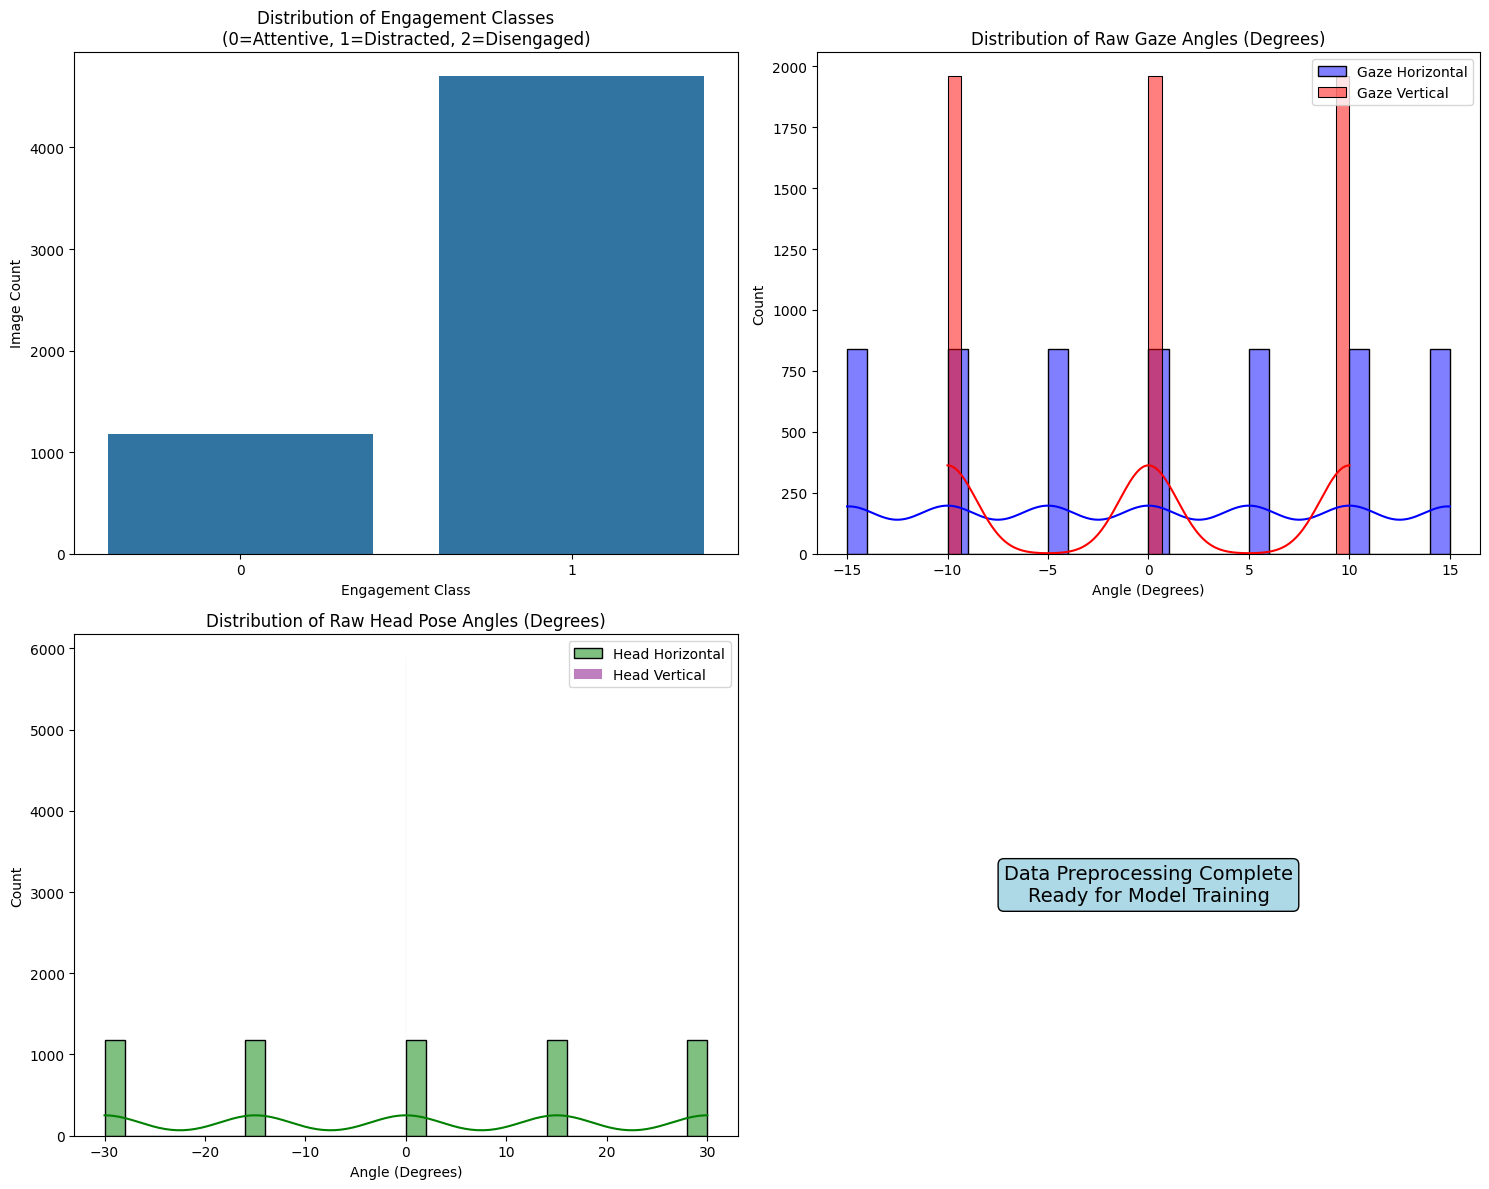

Visualizations displayed in notebook output.
Splitting data by subject...
Training subjects (44): [ 2  3  5  7  8  9 10 11 12 15 16 17 18 19 21 22 23 24 25 26 28 29 30 31
 32 33 35 36 38 39 40 41 42 43 44 46 47 48 49 50 52 53 54 56]
Test subjects (12): [ 1  4  6 13 14 20 27 34 37 45 51 55]
Training samples: 4620
Test samples: 1260

Preprocessing complete.
You are ready to train.
Example: `for inputs, labels in train_loader: ...`
Saved processed train and test label files.


In [10]:
import os
import cv2
import pandas as pd
import numpy as np
import re  
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "./columbia_gaze/"

IMG_SIZE = (224, 224)
TEST_SPLIT_SIZE = 0.2

def define_engagement_class(gaze_h, gaze_v, head_h, head_v):
    attentive_thresh_h = 15
    attentive_thresh_v = 15
    distracted_thresh_h = 30
    distracted_thresh_v = 25 
    
    if gaze_v <= -distracted_thresh_v or gaze_v >= distracted_thresh_v: 
        if gaze_v != 0:
             return 2 
    
    if abs(gaze_h) > distracted_thresh_h or abs(head_h) > distracted_thresh_h:
        return 1 
    if abs(gaze_h) <= attentive_thresh_h and abs(head_h) <= attentive_thresh_h and \
       gaze_v == 0:
        return 0 
   
    return 1 

def load_data_from_filenames(root_dir):
    data = []
    pattern = re.compile(r'^(\d+)_(\w+)_(-?\d+)P_(-?\d+)V_(-?\d+)H\.jpg$')
    
    print(f"Scanning directory: {root_dir}")
    
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('.jpg'):
                match = pattern.match(filename)
                if match:
                    subject_id = int(match.group(1))
                    head_h = int(match.group(3))
                    gaze_v = int(match.group(4))
                    gaze_h = int(match.group(5))
                    
                    data.append({
                        'subject_id': subject_id,
                        'image_file': filename,
                        'full_path': os.path.join(dirpath, filename),
                        'head_horizontal_angle': head_h,
                        'head_vertical_angle': 0, # *** CRITICAL ASSUMPTION ***
                        'gaze_vertical_angle': gaze_v,
                        'gaze_horizontal_angle': gaze_h
                    })
                elif filename.lower() != 'thumbs.db':
                    print(f"Warning: Skipping file with non-matching format: {filename}")
    
    if not data:
        print(f"FATAL ERROR: No .jpg files found or parsed in {root_dir}.")
        print("Check your DATA_DIR path. It should contain folders like /0001/, /0002/...")
        return None
        
    print(f"Successfully parsed {len(data)} image labels.")
    return pd.DataFrame(data)

def split_data(df):
    print("Splitting data by subject...")
    
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT_SIZE, random_state=42)
    
    train_indices, test_indices = next(splitter.split(df, groups=df['subject_id']))
    
    train_df = df.iloc[train_indices]
    test_df = df.iloc[test_indices]
    
    train_subjects = train_df['subject_id'].unique()
    test_subjects = test_df['subject_id'].unique()
    
    print(f"Training subjects ({len(train_subjects)}): {train_subjects}")
    print(f"Test subjects ({len(test_subjects)}): {test_subjects}")
    print(f"Training samples: {len(train_df)}")
    print(f"Test samples: {len(test_df)}")
    
    overlap = set(train_subjects).intersection(set(test_subjects))
    if len(overlap) > 0:
        print(f"WARNING: Subject split failed! Overlap: {overlap}")
        
    return train_df, test_df

class EyeGazeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['full_path']
        label = row['engagement_class']
        
        # Load image (OpenCV loads in BGR format)
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not read image {img_path}. Returning None.")
            image = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
            label = -1 
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def run_visualizations(df):
    print("Generating visualizations...")
    
    # Create a figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Class distribution
    sns.countplot(x='engagement_class', data=df, ax=axes[0,0])
    axes[0,0].set_title('Distribution of Engagement Classes\n(0=Attentive, 1=Distracted, 2=Disengaged)')
    axes[0,0].set_xlabel('Engagement Class')
    axes[0,0].set_ylabel('Image Count')
    
    # Plot 2: Gaze angles distribution
    sns.histplot(df['gaze_horizontal_angle'], color='blue', label='Gaze Horizontal', kde=True, bins=30, ax=axes[0,1])
    sns.histplot(df['gaze_vertical_angle'], color='red', label='Gaze Vertical', kde=True, bins=30, ax=axes[0,1])
    axes[0,1].set_title('Distribution of Raw Gaze Angles (Degrees)')
    axes[0,1].set_xlabel('Angle (Degrees)')
    axes[0,1].legend()
    
    # Plot 3: Head angles distribution
    sns.histplot(df['head_horizontal_angle'], color='green', label='Head Horizontal', kde=True, bins=30, ax=axes[1,0])
    sns.histplot(df['head_vertical_angle'], color='purple', label='Head Vertical', kde=True, bins=30, ax=axes[1,0])
    axes[1,0].set_title('Distribution of Raw Head Pose Angles (Degrees)')
    axes[1,0].set_xlabel('Angle (Degrees)')
    axes[1,0].legend()
    
    # Plot 4: Class distribution by subject (empty for now, can be customized)
    axes[1,1].axis('off')
    axes[1,1].text(0.5, 0.5, 'Data Preprocessing Complete\nReady for Model Training', 
                   horizontalalignment='center', verticalalignment='center', 
                   transform=axes[1,1].transAxes, fontsize=14, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    plt.tight_layout()
    plt.show()
    
    print("Visualizations displayed in notebook output.")

def main():
    print("Starting preprocessing pipeline...")
    
    df = load_data_from_filenames(DATA_DIR)
    if df is None:
        return
        
    df['engagement_class'] = df.apply(
        lambda row: define_engagement_class(
            row['gaze_horizontal_angle'], 
            row['gaze_vertical_angle'],
            row['head_horizontal_angle'],
            row['head_vertical_angle']
        ),
        axis=1
    )
    
    print("Class label application complete.")
    print("Class counts:\n", df['engagement_class'].value_counts())
    
    run_visualizations(df)
    
    train_df, test_df = split_data(df)
    
    data_transforms = {
        'train': transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'test': transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    train_dataset = EyeGazeDataset(train_df, transform=data_transforms['train'])
    test_dataset = EyeGazeDataset(test_df, transform=data_transforms['test'])
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    print("\nPreprocessing complete.")
    print("You are ready to train.")
    print(f"Example: `for inputs, labels in train_loader: ...`")
    
    train_df.to_csv(os.path.join(DATA_DIR, 'train_labels.csv'), index=False)
    test_df.to_csv(os.path.join(DATA_DIR, 'test_labels.csv'), index=False)
    print("Saved processed train and test label files.")

if __name__ == "__main__":
    main()

In [11]:
import os
import cv2
import re
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
import mediapipe as mp

# Configuration
DATA_DIR = "./columbia_gaze/"
MODEL_PATH = 'resnet18.pth'
IMG_SIZE = (224, 224)
TEST_SPLIT_SIZE = 0.2

# 2. Model Architecture (ResNet-18)

We utilize a ResNet-18 architecture modified for 3-class classification. The model was trained on the processed Columbia Gaze dataset using a T4 GPU cluster (Kaggle).

We load the pre-trained weights here to prepare for the inference stage. A custom loading function is implemented to handle the module. A prefix compatibility issue arises when moving weights from a multi-GPU environment (DataParallel) to a single local CPU/GPU.

In [16]:
def load_trained_model(model_path, device):
    print(f"Loading model from {model_path}...")
    
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 3)
    
    
    try:
        state_dict = torch.load(model_path, map_location=device)
        
        # Fix DataParallel 'module.' prefix mismatch
        from collections import OrderedDict
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] if k.startswith('module.') else k 
            new_state_dict[name] = v
            
        model.load_state_dict(new_state_dict)
        model = model.to(device)
        model.eval()
        print("Model weights loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

# Initialize Model
DEVICE = torch.device('cpu')
model = load_trained_model(MODEL_PATH, DEVICE)

Loading model from resnet18.pth...
Model weights loaded successfully.


# 3. Real-Time Hybrid Inference System

The final system integrates Deep Learning with Geometric Computer Vision to solve the domain shift problem inherent in webcam feeds.

## The Hybrid Logic:

- **Iris Tracking (MediaPipe):** We extract landmarks 468-477 (Iris) to calculate the horizontal "Gaze Ratio." If the iris deviates from the eye center, we override the model and flag "Distracted (Eyes)."

- **Contextual Analysis (ResNet-18):** If the eyes are centered, we pass the facial crop to the ResNet model to detect head-pose-based distraction or disengagement (e.g., looking down).

This ensemble approach ensures robustness against lighting changes and subtle eye movements.

In [24]:
# Constants for MediaPipe Face Mesh
LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
LEFT_IRIS = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]
CLASS_NAMES = {0: 'Attentive', 1: 'Distracted', 2: 'Disengaged'}

# Preprocessing Transform
inference_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def get_gaze_ratio(img, landmarks, eye_indices, iris_indices):
    """Calculates the relative position of the iris within the eye landmarks."""
    eye_points = np.array([(landmarks[i].x * img.shape[1], landmarks[i].y * img.shape[0]) 
                          for i in eye_indices], dtype=np.int32)
    iris_points = np.array([(landmarks[i].x * img.shape[1], landmarks[i].y * img.shape[0]) 
                           for i in iris_indices], dtype=np.int32)
    
    if len(eye_points) == 0 or len(iris_points) == 0: return 0.5
    
    iris_center = np.mean(iris_points, axis=0)
    left_corner = eye_points[0] 
    right_corner = eye_points[3]
    
    eye_width = np.linalg.norm(right_corner - left_corner)
    if eye_width == 0: return 0.5
    
    dist_to_left = np.linalg.norm(iris_center - left_corner)
    return dist_to_left / eye_width

def run_hybrid_inference():
    if model is None:
        print("Model not loaded. Cannot start inference.")
        return

    mp_face_mesh = mp.solutions.face_mesh
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Webcam not accessible.")
        return

    print("Starting Hybrid System... Press 'q' to quit.")

    with mp_face_mesh.FaceMesh(
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as face_mesh:

        while True:
            ret, frame = cap.read()
            if not ret: 
                print("Failed to grab frame")
                break
            
            frame = cv2.flip(frame, 1) 
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img_h, img_w = frame.shape[:2]
            
            results = face_mesh.process(rgb_frame)
            
            prediction = "Searching..."
            status_color = (100, 100, 100)
            confidence = 0.0
            
            if results.multi_face_landmarks:
                mesh_points = results.multi_face_landmarks[0].landmark
                
                # 1. Geometric Iris Analysis
                right_ratio = get_gaze_ratio(frame, mesh_points, RIGHT_EYE, RIGHT_IRIS)
                left_ratio = get_gaze_ratio(frame, mesh_points, LEFT_EYE, LEFT_IRIS)
                avg_ratio = (right_ratio + left_ratio) / 2
                
                gaze_status = "Center"
                if avg_ratio < 0.42: 
                    gaze_status = "Looking Right"
                elif avg_ratio > 0.58: 
                    gaze_status = "Looking Left"
                
                # 2. Deep Learning Analysis (Global Context)
                x_coords = [p.x for p in mesh_points]
                y_coords = [p.y for p in mesh_points]
                x_min, x_max = int(min(x_coords) * img_w), int(max(x_coords) * img_w)
                y_min, y_max = int(min(y_coords) * img_h), int(max(y_coords) * img_h)
                
                # Pad and Crop
                pad = 20
                x_min, y_min = max(0, x_min-pad), max(0, y_min-pad)
                x_max, y_max = min(img_w, x_max+pad), min(img_h, y_max+pad)
                
                face_img = rgb_frame[y_min:y_max, x_min:x_max]
                model_pred = "Unknown"
                model_confidence = 0.0
                
                if face_img.size > 0 and face_img.shape[0] > 10 and face_img.shape[1] > 10:
                    try:
                        pil_img = Image.fromarray(face_img)
                        input_tensor = inference_transform(pil_img).unsqueeze(0).to(DEVICE)
                        
                        with torch.no_grad():
                            outputs = model(input_tensor)
                            probs = F.softmax(outputs, dim=1)[0]
                            confidence, preds = torch.max(probs, 0)
                            model_pred = CLASS_NAMES[preds.item()]
                            model_confidence = confidence.item()
                    except Exception as e:
                        print(f"Model inference error: {e}")
                        model_pred = "Unknown"

                # 3. Ensemble Decision Logic
                if gaze_status != "Center":
                    # If eyes are looking away, mark as distracted
                    prediction = f"Distracted (Eyes {gaze_status.split(' ')[1]})"
                    status_color = (0, 0, 255)  # Red
                elif model_pred == "Disengaged":
                    # If model detects disengaged (head down/looking away)
                    prediction = f"Disengaged ({model_confidence:.2f})"
                    status_color = (0, 0, 255)  # Red
                elif model_pred == "Distracted":
                    # If model detects distracted but eyes are center
                    prediction = f"Distracted ({model_confidence:.2f})"
                    status_color = (0, 165, 255)  # Orange
                else:
                    # Attentive case
                    prediction = f"Attentive ({model_confidence:.2f})"
                    status_color = (0, 255, 0)  # Green

                # Visualization
                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), status_color, 2)
                
                # Visualize Iris
                p_iris_L = mesh_points[473]
                p_iris_R = mesh_points[468]
                cv2.circle(frame, (int(p_iris_L.x * img_w), int(p_iris_L.y * img_h)), 3, (0, 255, 255), -1)
                cv2.circle(frame, (int(p_iris_R.x * img_w), int(p_iris_R.y * img_h)), 3, (0, 255, 255), -1)
                
                # Display gaze information
                cv2.putText(frame, f"Gaze: {gaze_status} ({avg_ratio:.2f})", 
                           (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

            # Display main prediction
            cv2.putText(frame, f"Status: {prediction}", (20, 50), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, status_color, 2)
            
            # Display instructions
            cv2.putText(frame, "Press 'q' to quit", (20, img_h - 20), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # Create window at half screen size
            cv2.namedWindow('Engagement Analysis System', cv2.WINDOW_NORMAL)
            
            # Get screen dimensions and set window to half size
            screen_width = 1920  # You can adjust this based on your screen resolution
            screen_height = 1080
            window_width = screen_width // 2
            window_height = screen_height // 2
            
            # Position window in the center of the screen
            x_position = (screen_width - window_width) // 2
            y_position = (screen_height - window_height) // 2
            
            cv2.resizeWindow('Engagement Analysis System', window_width, window_height)
            cv2.moveWindow('Engagement Analysis System', x_position, y_position)
            
            cv2.imshow('Engagement Analysis System', frame)
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()
    print("Camera released. System shutdown.")

if __name__ == '__main__':
    run_hybrid_inference()

Starting Hybrid System... Press 'q' to quit.
Camera released. System shutdown.
